# EdTech Learning Behavior and Student Performance Analytics Using Machine Learning

**Student Name:** Muhammad Ahsan

**Dataset Source:** https://www.kaggle.com/datasets/adilshamim8/student-performance-and-learning-style

**Dataset File:** student_performance.csv

**Project Overview**
This project analyzes student learning behavior, academic engagement, and educational technology usage to identify factors affecting academic performance and to build predictive machine learning models.

**Project Objectives**
- Explore the dataset structure and data quality.
- Analyze student behavior, engagement, and performance patterns.
- Study relationships between learning factors and academic outcomes.
- Build regression models for ExamScore prediction.
- Build classification models for FinalGrade prediction.
- Compare model performance and present business recommendations.

## 2. Import Libraries

This notebook uses pandas and numpy for data handling, matplotlib and seaborn for visualization, and scikit-learn for model building. Warnings are suppressed so the final notebook remains clean and presentation-ready.

In [1]:
# Import libraries and set presentation-friendly defaults

import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

## 3. Dataset Loading

The dataset is loaded directly from the project folder to keep the workflow reproducible. The first rows and shape are reviewed immediately so the analysis starts with a quick verification of the file contents.

In [2]:
# Load the dataset and inspect the first rows

df = pd.read_csv("student_performance.csv")
display(df.head())
print(f"Dataset shape: {df.shape}")

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


Dataset shape: (14003, 16)


## 4. Dataset Understanding

Before any modeling, the dataset structure should be understood clearly. This step reviews the schema, summary statistics, missing values, duplicates, and feature types so the later analysis is based on clean and well-defined inputs.

In [3]:
# Inspect columns, data types, summary statistics, and feature groups

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame(name="dtype"))

print("\nStatistical summary:")
display(df.describe().T)

print("\nMissing values:")
display(df.isnull().sum().to_frame(name="missing_values"))

print(f"\nDuplicate rows: {df.duplicated().sum()}")

print("\nDataset information:")
df.info()

feature_groups = pd.DataFrame({
    "Category": ["Continuous numeric", "Encoded categorical", "Targets"],
    "Features": [
        "StudyHours, Attendance, Age, OnlineCourses, Discussions, AssignmentCompletion",
        "Resources, Extracurricular, Motivation, Internet, Gender, LearningStyle, EduTech, StressLevel",
        "ExamScore, FinalGrade"
    ]
})
display(feature_groups)

Column names:
['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']

Data types:


,dtype
StudyHours,int64
Attendance,int64
Resources,int64
Extracurricular,int64
Motivation,int64
Internet,int64
Gender,int64
Age,int64
LearningStyle,int64
OnlineCourses,int64



Statistical summary:


,count,mean,std,min,25%,50%,75%,max
StudyHours,14003.0,19.987431,5.890637,5.0,16.0,20.0,24.0,44.0
Attendance,14003.0,80.194316,11.472181,60.0,70.0,80.0,90.0,100.0
Resources,14003.0,1.104406,0.697362,0.0,1.0,1.0,2.0,2.0
Extracurricular,14003.0,0.594158,0.491072,0.0,0.0,1.0,1.0,1.0
Motivation,14003.0,0.905806,0.695896,0.0,0.0,1.0,1.0,2.0
Internet,14003.0,0.925516,0.262566,0.0,1.0,1.0,1.0,1.0
Gender,14003.0,0.551953,0.497311,0.0,0.0,1.0,1.0,1.0
Age,14003.0,23.532172,3.514293,18.0,20.0,24.0,27.0,29.0
LearningStyle,14003.0,1.515461,1.112941,0.0,1.0,2.0,3.0,3.0
OnlineCourses,14003.0,9.891952,6.112801,0.0,5.0,10.0,15.0,20.0



Missing values:


,missing_values
StudyHours,0
Attendance,0
Resources,0
Extracurricular,0
Motivation,0
Internet,0
Gender,0
Age,0
LearningStyle,0
OnlineCourses,0



Duplicate rows: 1534

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrad

,Category,Features
0,Continuous numeric,"StudyHours, Attendance, Age, OnlineCourses, Di..."
1,Encoded categorical,"Resources, Extracurricular, Motivation, Intern..."
2,Targets,"ExamScore, FinalGrade"


## 5. Data Cleaning

The dataset is already well structured, with no missing values and no obvious data-entry issues. Duplicate records are removed for cleaner analysis, while the boxplots are used to check whether the extreme values appear to be genuine variation or obvious errors. The observed outliers are retained because they are plausible student records and may carry useful signal.

Rows before cleaning: 14003
Rows after cleaning: 12469
Duplicate rows removed: 1534
Missing values after cleaning: 0


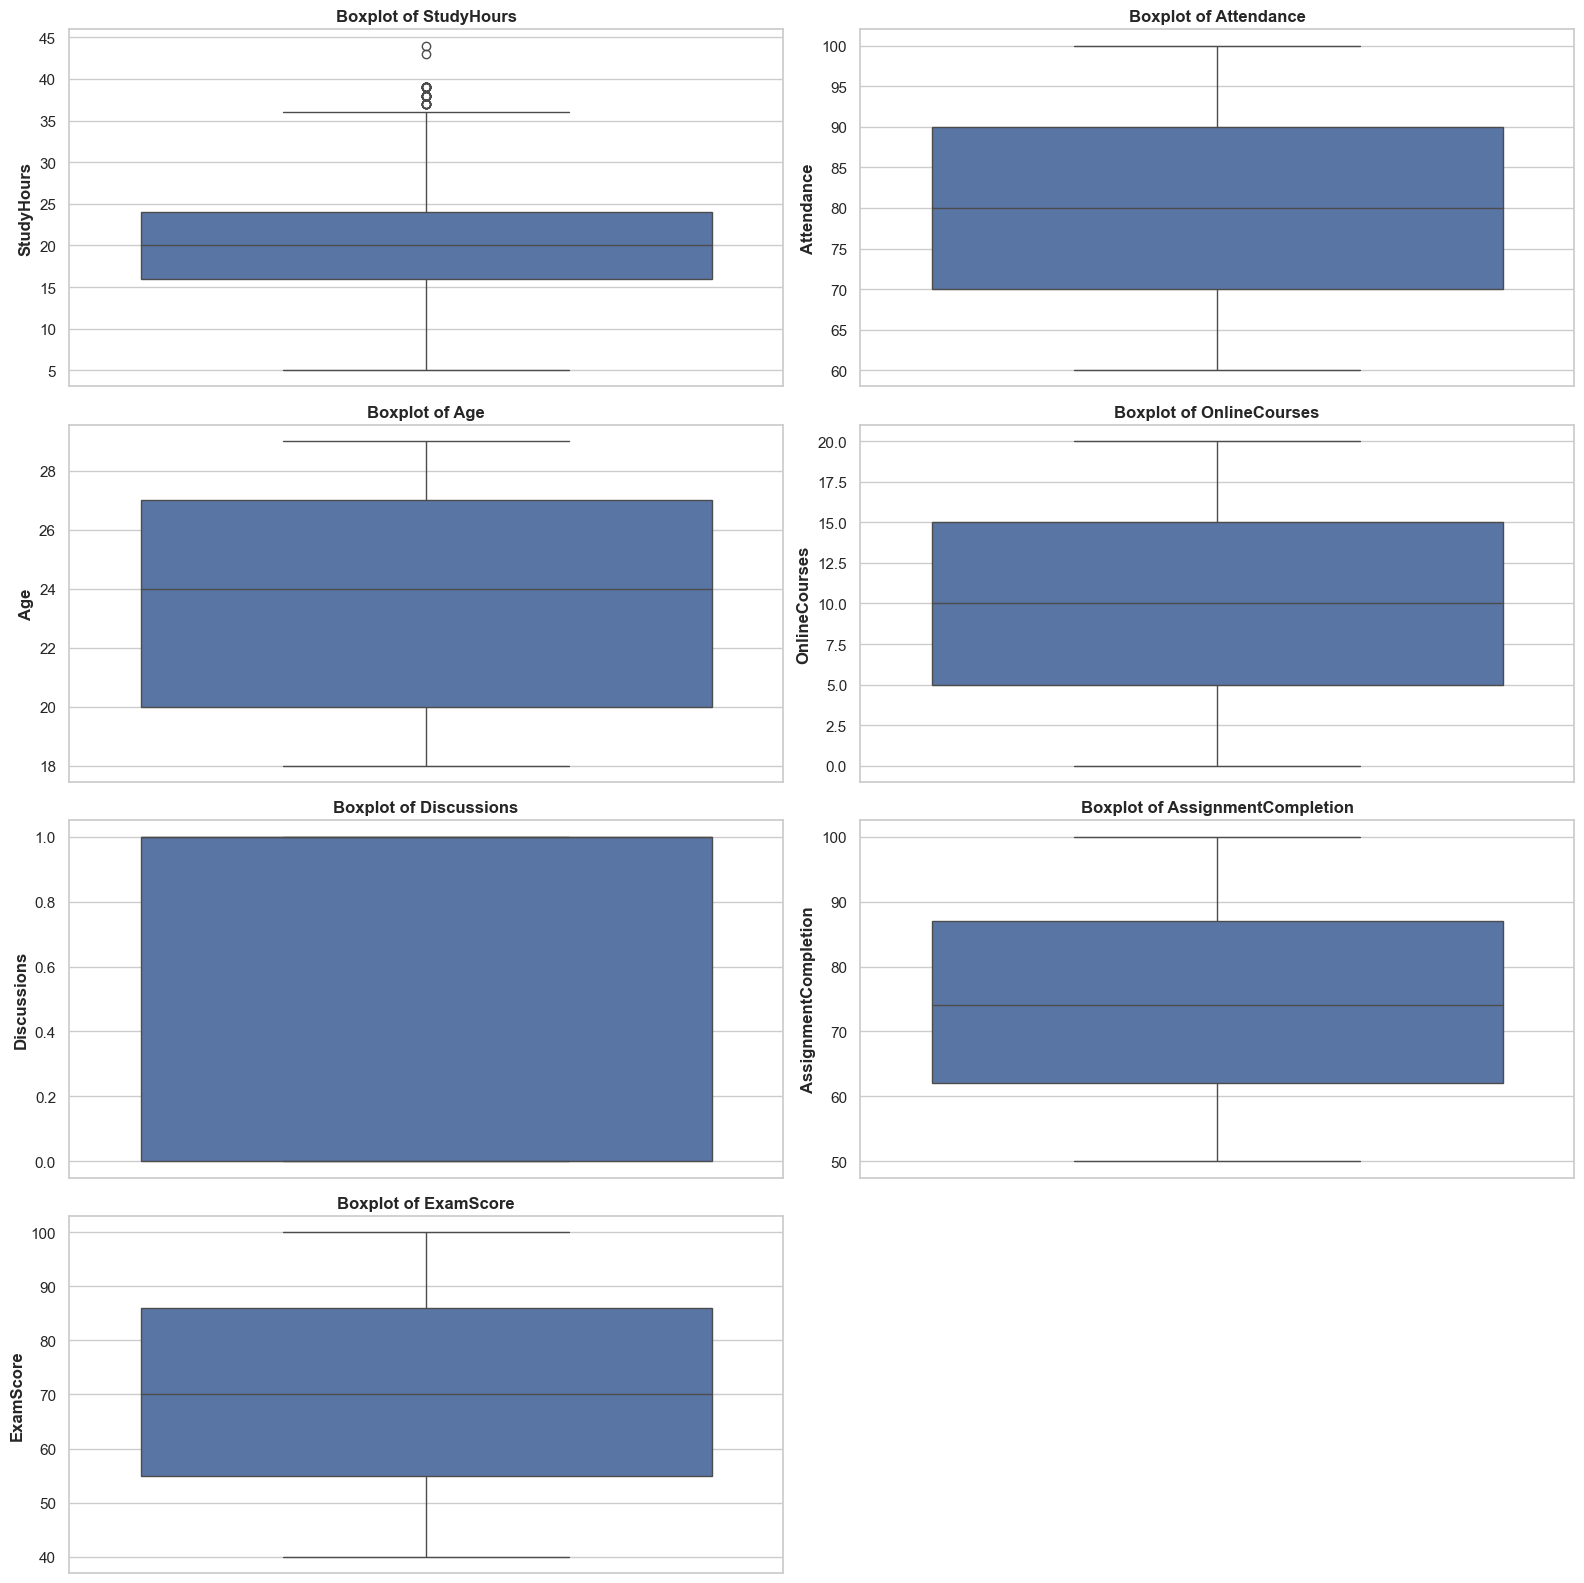

,Feature,Outlier Count,Lower Bound,Upper Bound
0,StudyHours,45,4.0,36.0
1,Attendance,0,40.0,120.0
2,Age,0,9.5,37.5
3,OnlineCourses,0,-10.0,30.0
4,Discussions,0,-1.5,2.5
5,AssignmentCompletion,0,24.5,124.5
6,ExamScore,0,8.5,132.5


In [4]:
# Remove duplicate rows and check for data consistency issues

df_clean = df.drop_duplicates().reset_index(drop=True)
removed_duplicates = len(df) - len(df_clean)

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Duplicate rows removed: {removed_duplicates}")
print(f"Missing values after cleaning: {int(df_clean.isnull().sum().sum())}")

boxplot_features = [column for column in ["StudyHours", "Attendance", "Age", "OnlineCourses", "Discussions", "AssignmentCompletion", "ExamScore"] if column in df_clean.columns]
boxplot_rows = math.ceil(len(boxplot_features) / 2)
fig, axes = plt.subplots(boxplot_rows, 2, figsize=(16, 4 * boxplot_rows))
axes = np.array(axes).flatten()
for index, column in enumerate(boxplot_features):
    sns.boxplot(y=df_clean[column], ax=axes[index], color="#4C72B0")
    axes[index].set_title(f"Boxplot of {column}")
    axes[index].set_xlabel("")
    axes[index].set_ylabel(column)
for axis in axes[len(boxplot_features):]:
    axis.axis("off")
plt.tight_layout()
plt.show()

outlier_summary = []
for column in boxplot_features:
    q1 = df_clean[column].quantile(0.25)
    q3 = df_clean[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = df_clean[(df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)].shape[0]
    outlier_summary.append({
        "Feature": column,
        "Outlier Count": outlier_count,
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2)
    })

display(pd.DataFrame(outlier_summary).sort_values("Outlier Count", ascending=False))

## 6. EDA Observations

The plots show a clear performance story built around engagement and consistency. Study hours, attendance, and assignment completion appear to be the most informative behavioral signals, while stress level and technology usage help explain differences in student outcomes. Correlation patterns are descriptive rather than causal, so they should be used to guide further analysis and model interpretation.

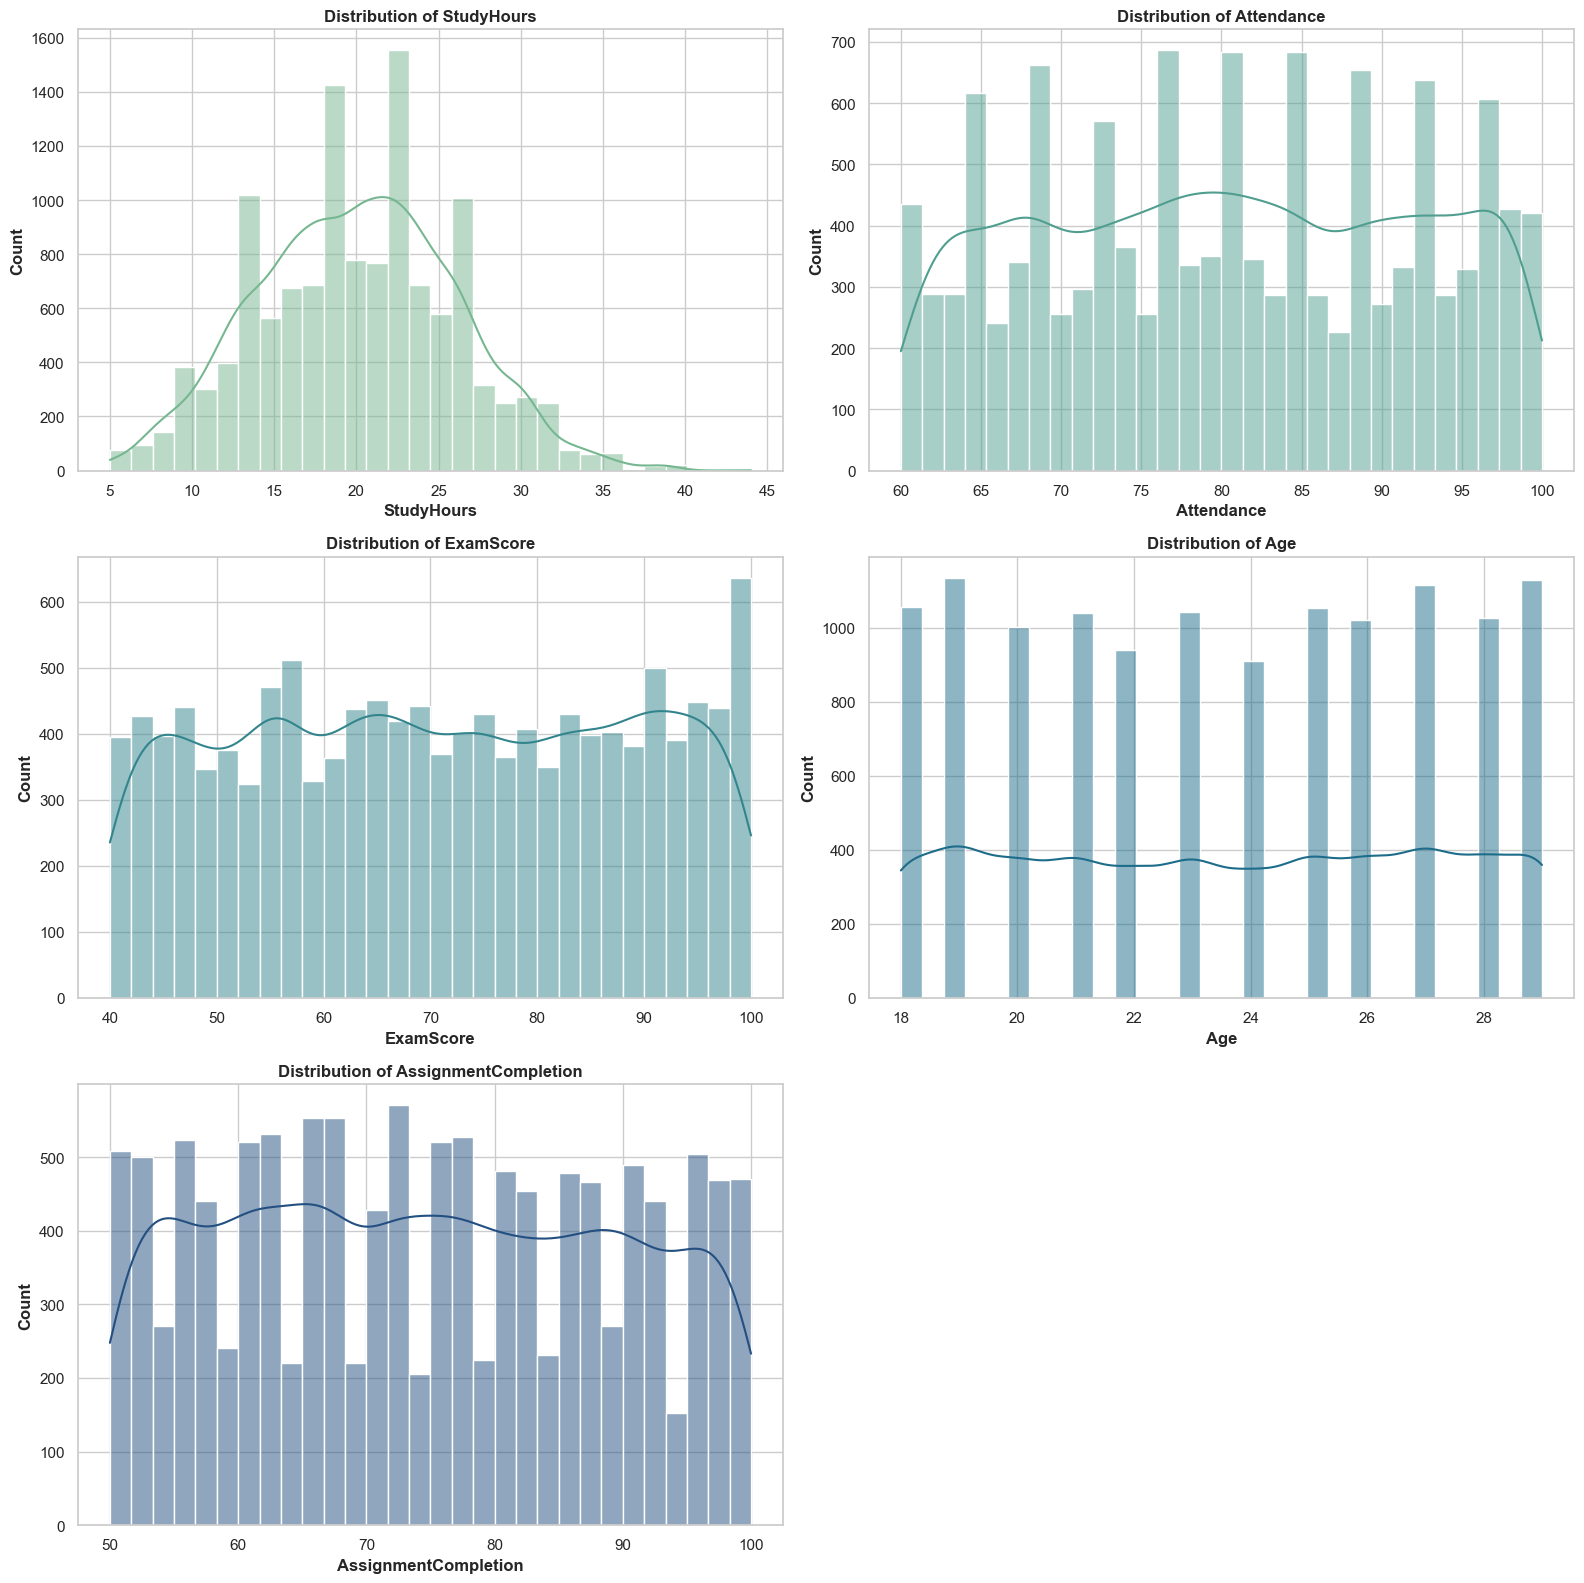

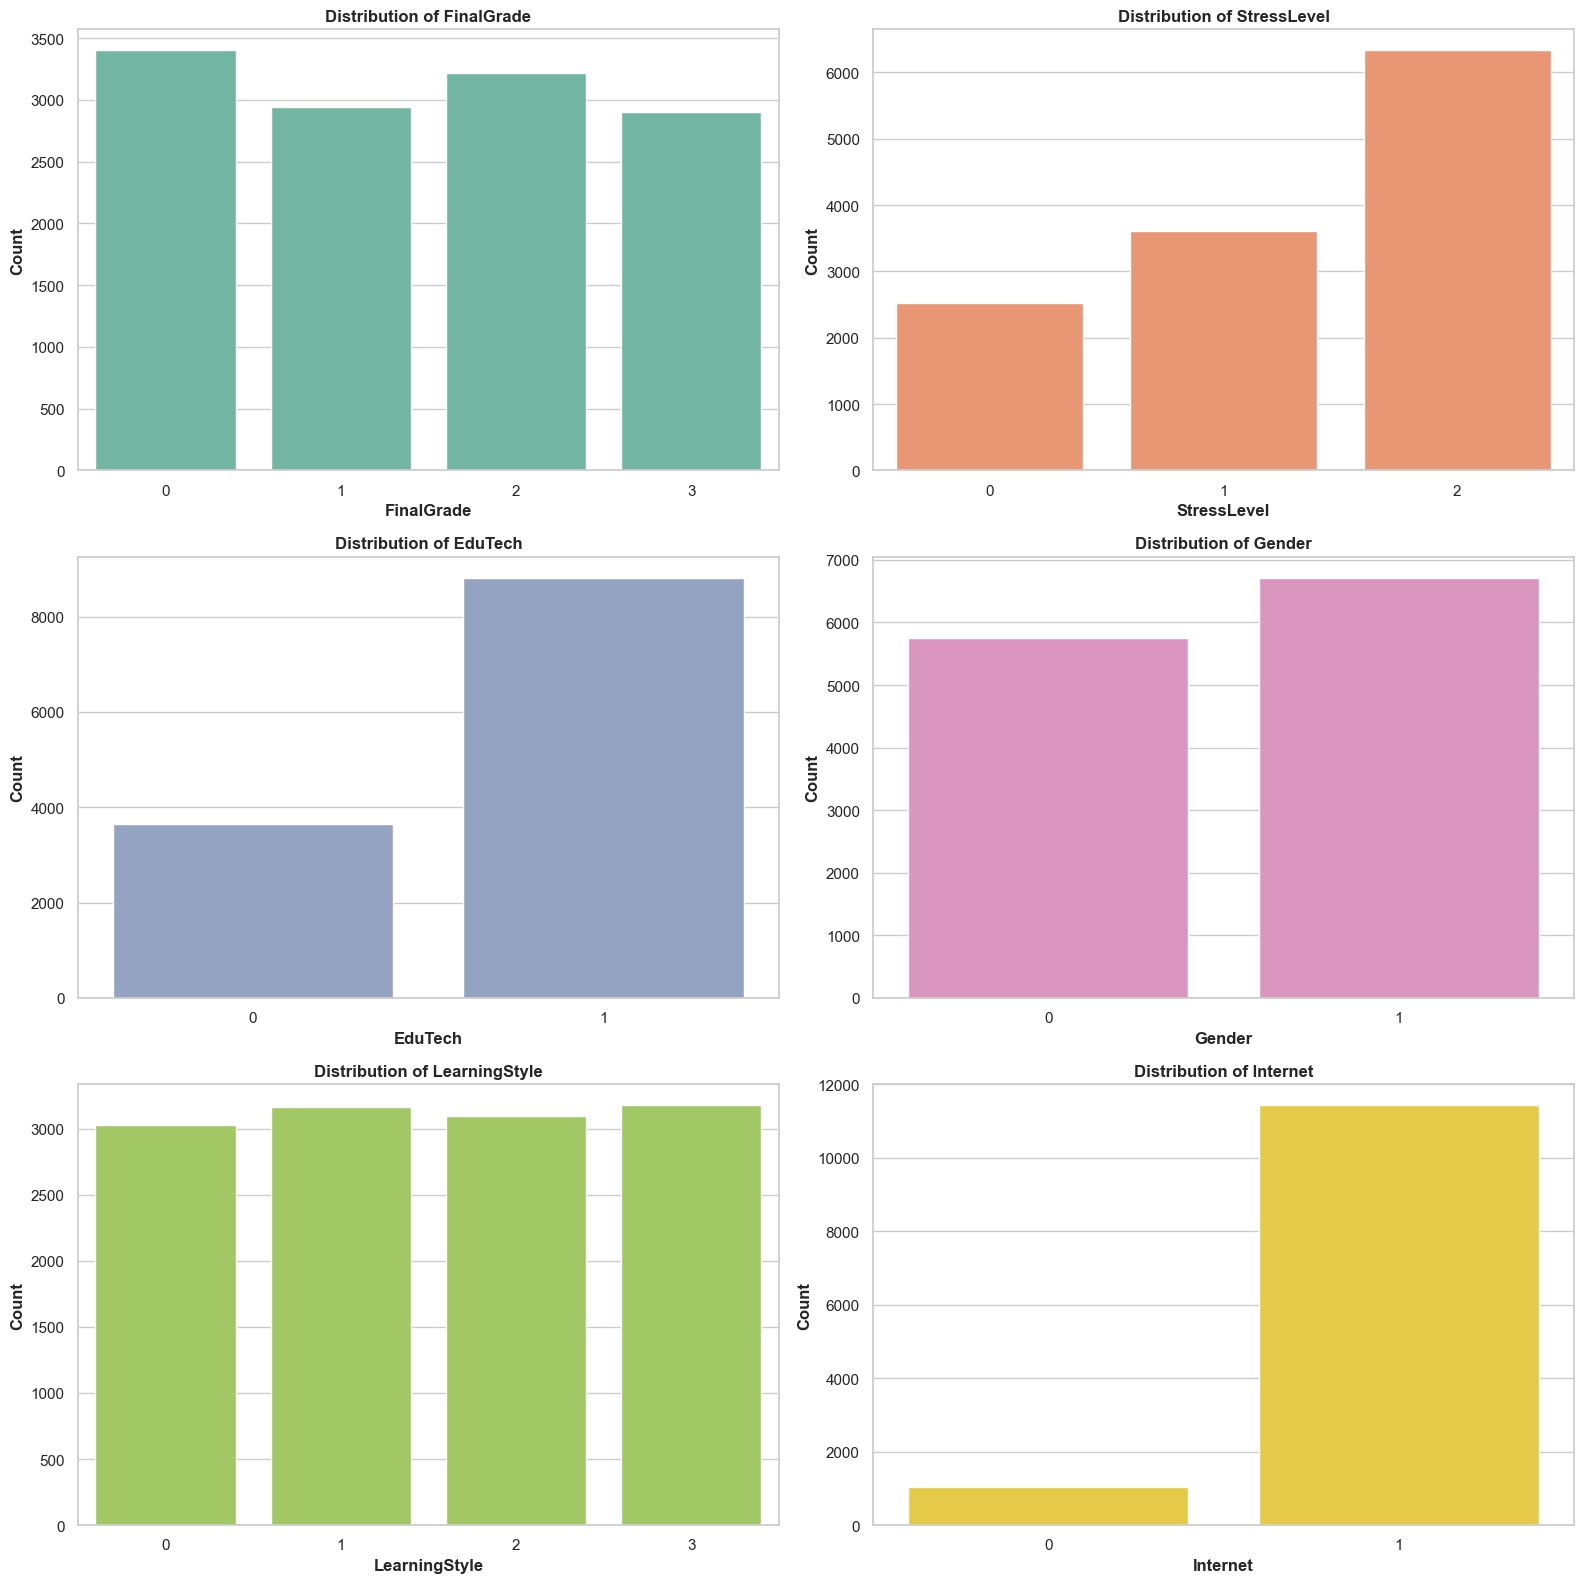

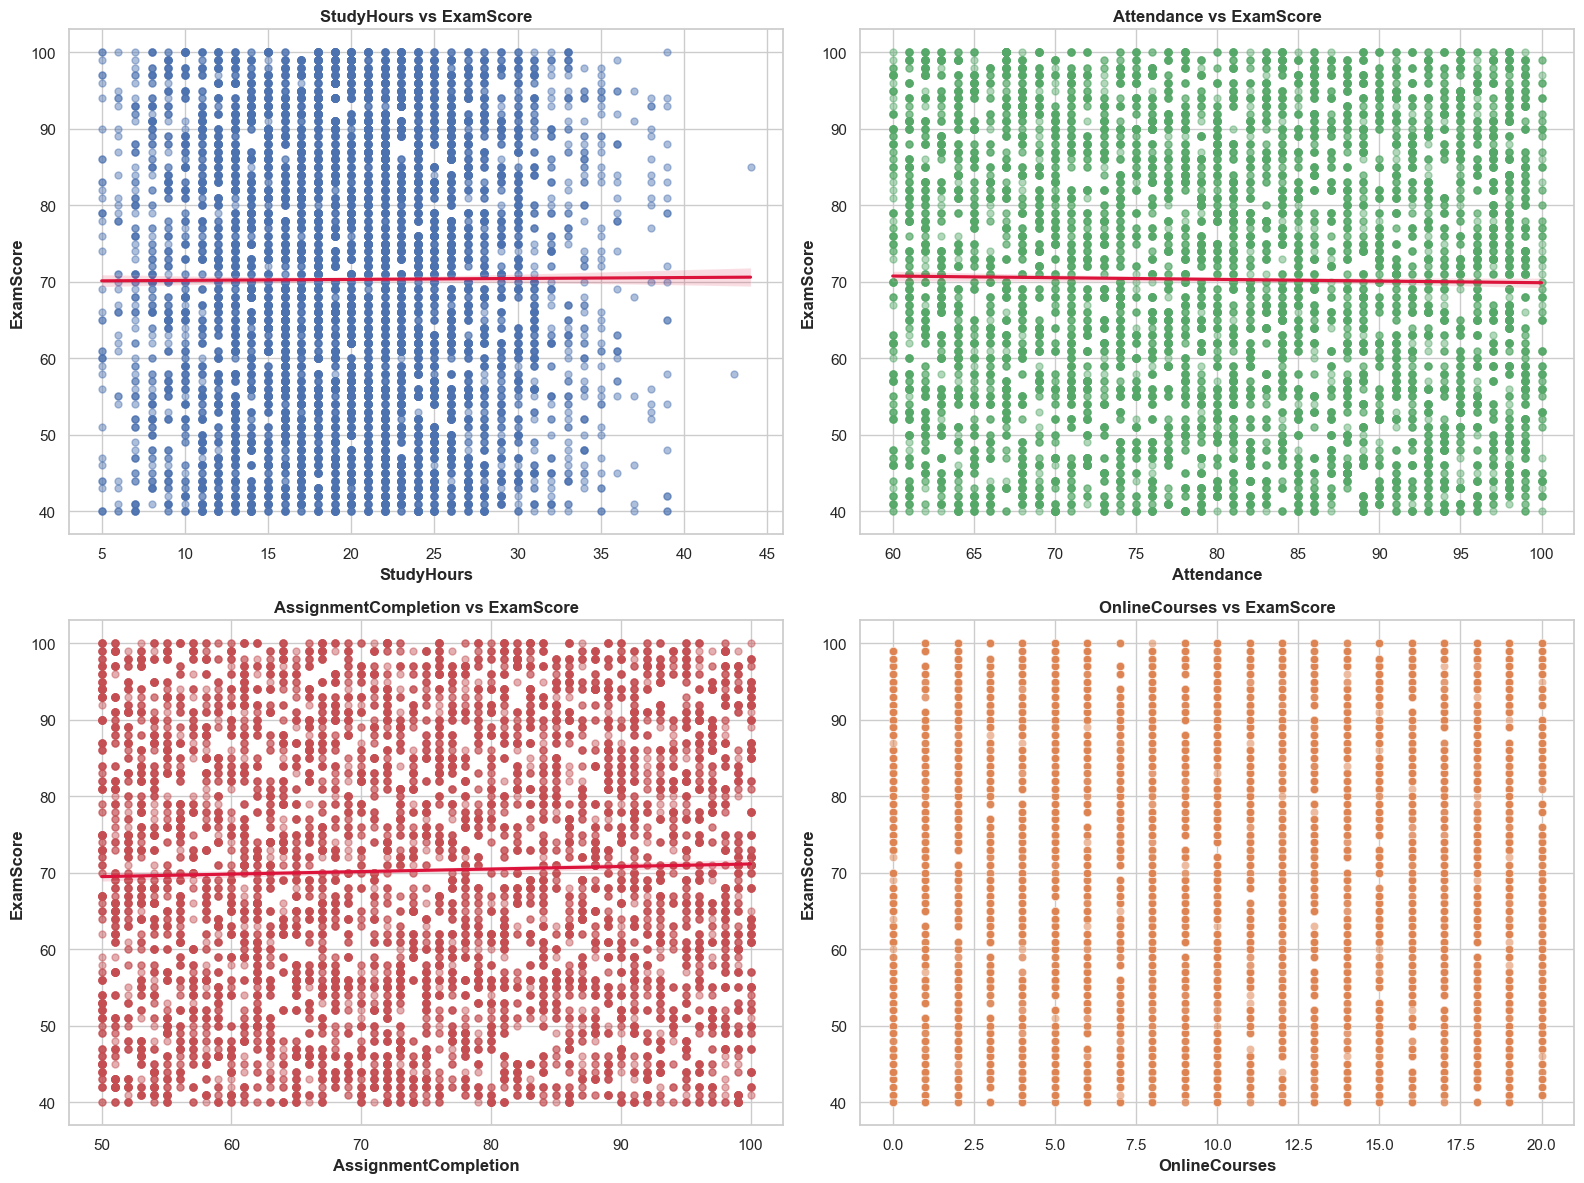

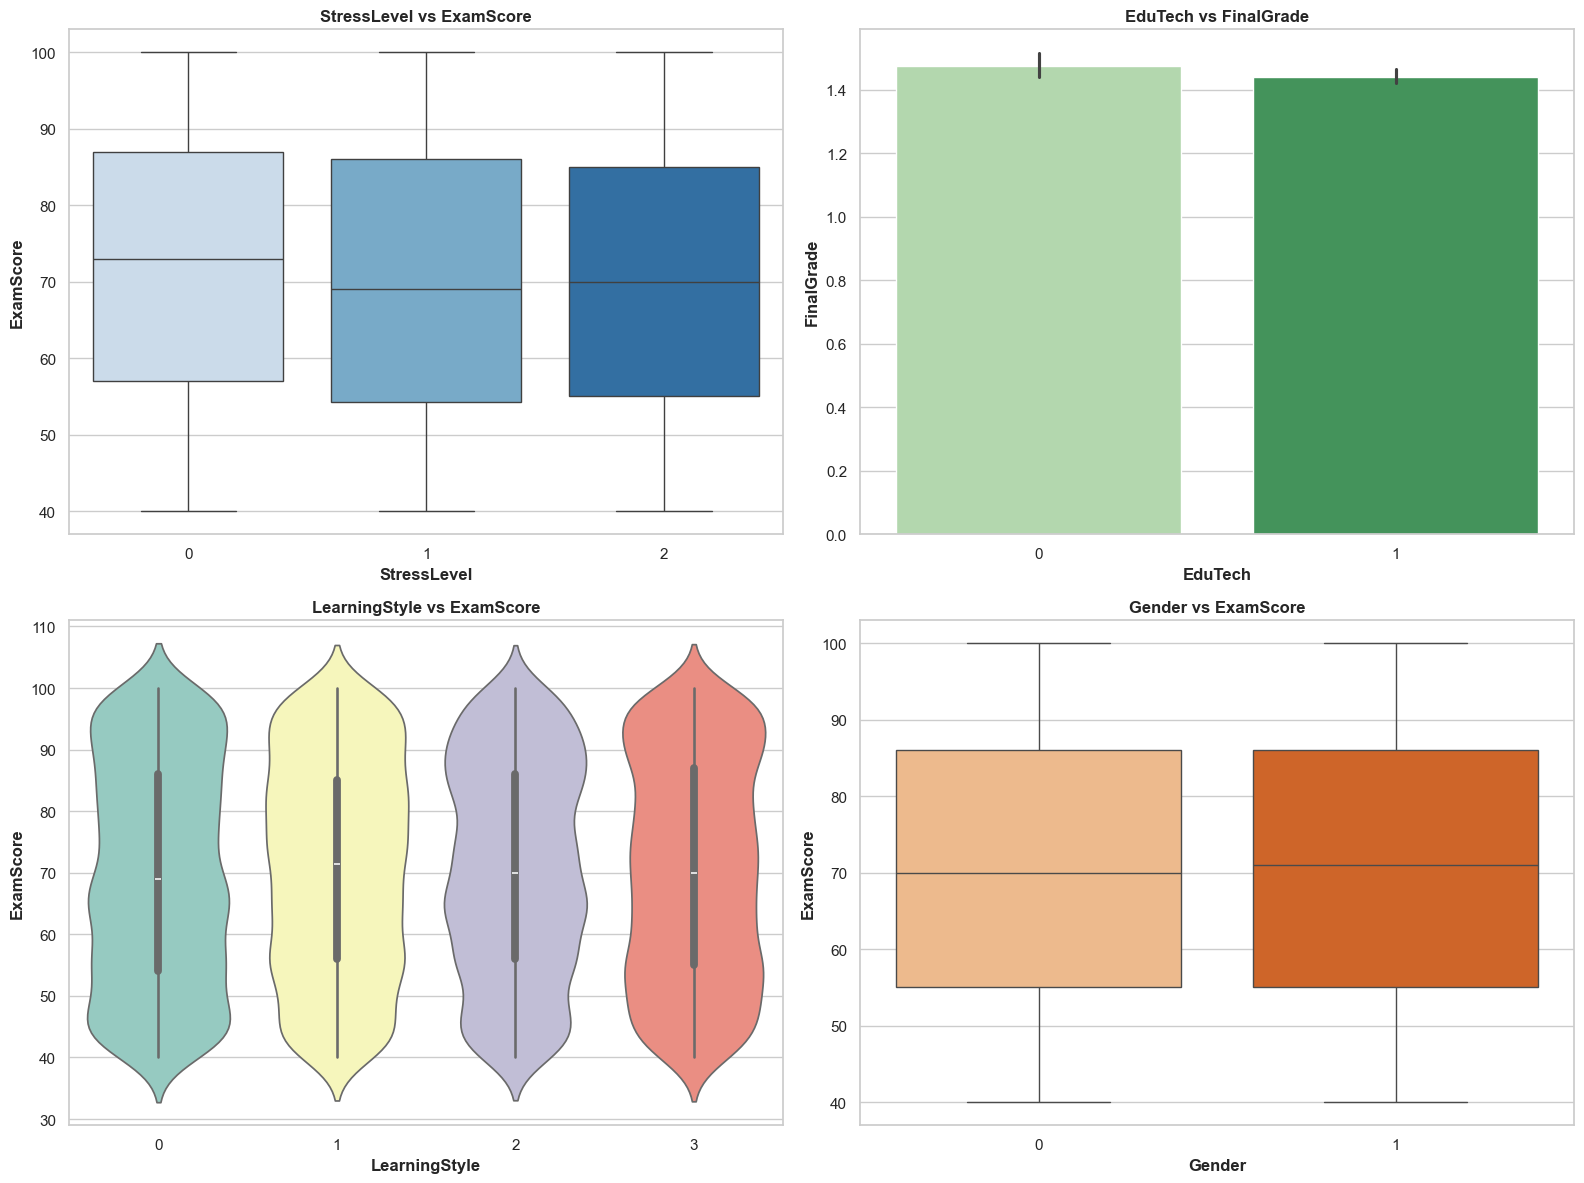

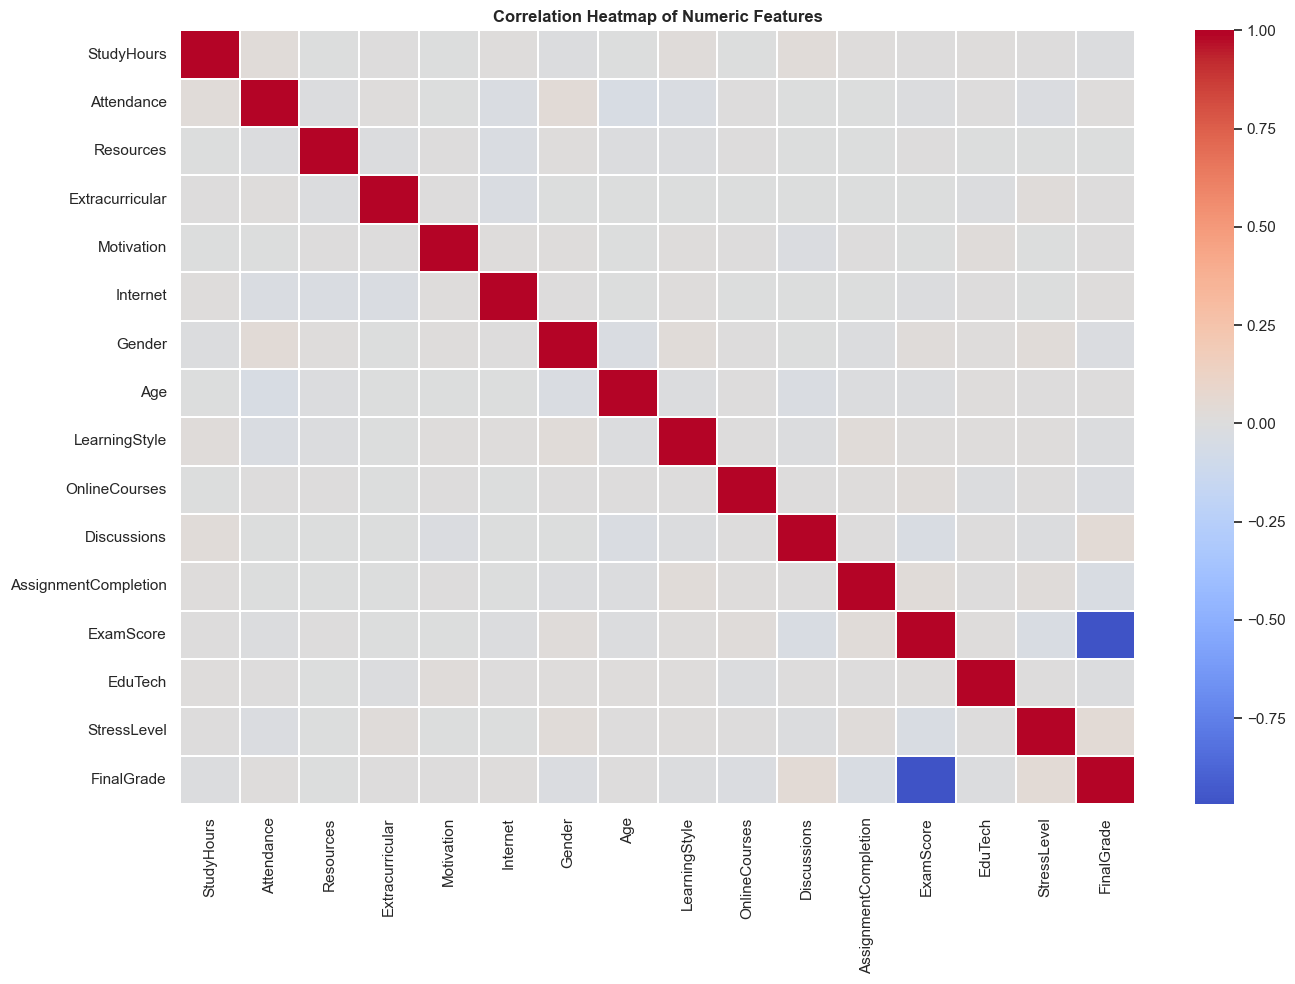

Strongest positive correlations with ExamScore:


,Correlation
AssignmentCompletion,0.027402
OnlineCourses,0.020684
Gender,0.016750
EduTech,0.010311
LearningStyle,0.008282


Strongest negative correlations with ExamScore:


,Correlation
FinalGrade,-0.968365
StressLevel,-0.034324
Discussions,-0.031209
Attendance,-0.014156
Age,-0.010137


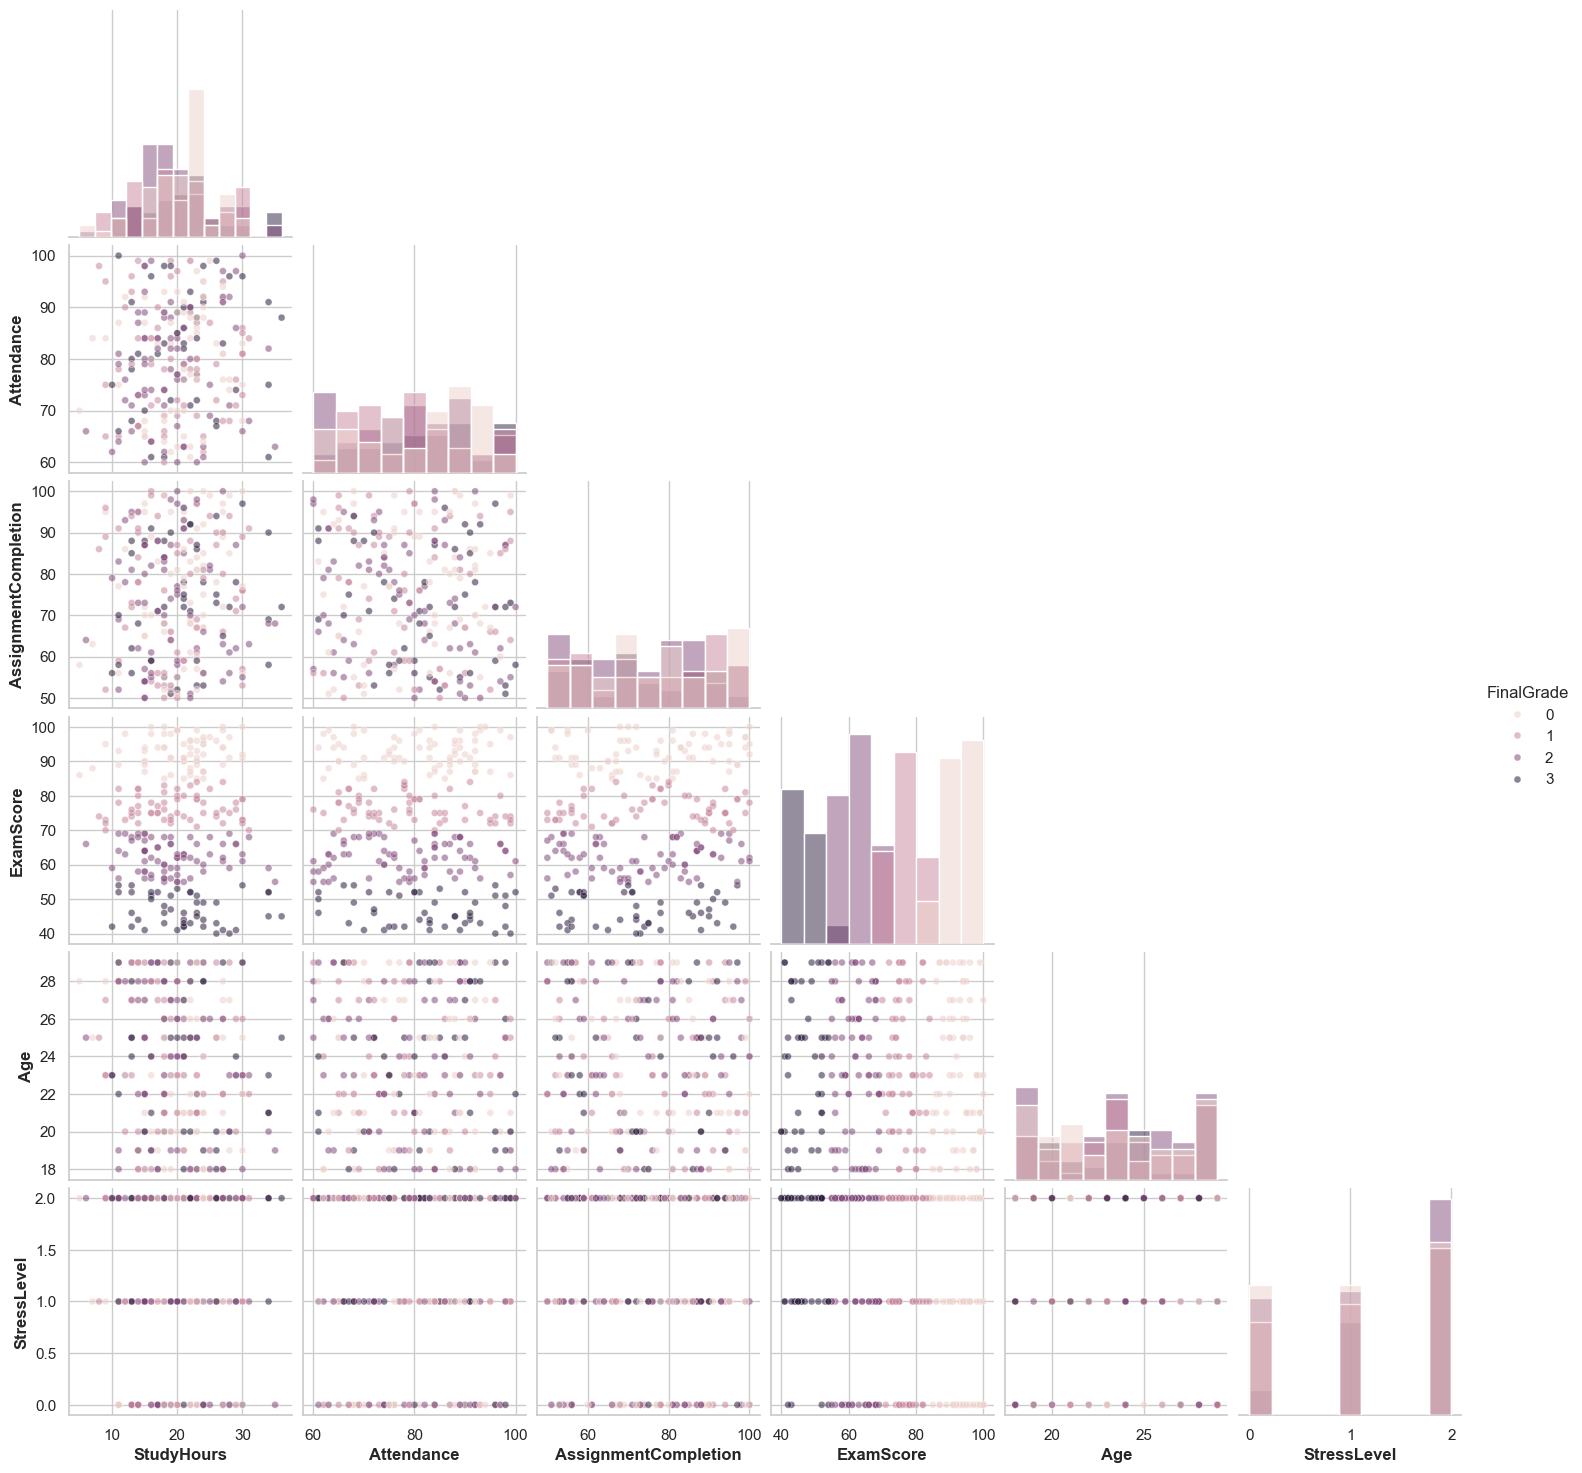

,StressLevel,ExamScore,StudyHours,Attendance,AssignmentCompletion
0,0,71.896593,19.963946,80.559033,74.165214
1,1,69.741561,20.040675,80.350028,74.357775
2,2,70.003317,20.058916,80.048492,74.744906


,EduTech,ExamScore,StudyHours,Attendance,AssignmentCompletion
0,0,70.027116,19.905231,80.143796,74.397151
1,1,70.428102,20.087888,80.278748,74.564300


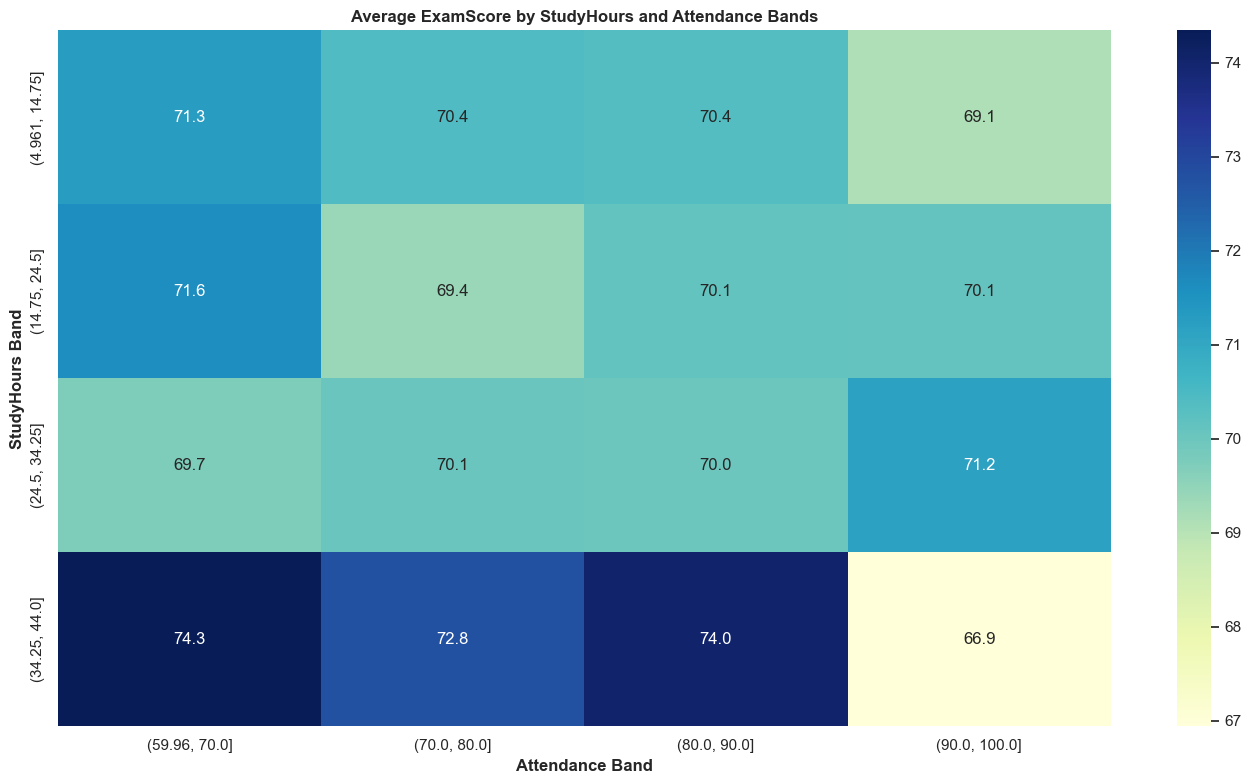

In [5]:
# EDA: distributions, category counts, relationships, correlations, and advanced pattern review

# -------------------------------
# Univariate Analysis
# -------------------------------
univariate_cols = [column for column in ["StudyHours", "Attendance", "ExamScore", "Age", "AssignmentCompletion"] if column in df_clean.columns]
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()
for index, column in enumerate(univariate_cols):
    sns.histplot(data=df_clean, x=column, kde=True, bins=30, ax=axes[index], color=sns.color_palette("crest", len(univariate_cols))[index])
    axes[index].set_title(f"Distribution of {column}")
    axes[index].set_xlabel(column)
    axes[index].set_ylabel("Count")
for axis in axes[len(univariate_cols):]:
    axis.axis("off")
plt.tight_layout()
plt.show()

# -------------------------------
# Categorical Analysis
# -------------------------------
categorical_cols = [column for column in ["FinalGrade", "StressLevel", "EduTech", "Gender", "LearningStyle", "Internet"] if column in df_clean.columns]
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()
for index, column in enumerate(categorical_cols):
    order = sorted(df_clean[column].dropna().unique())
    sns.countplot(data=df_clean, x=column, order=order, ax=axes[index], color=sns.color_palette("Set2", len(categorical_cols))[index])
    axes[index].set_title(f"Distribution of {column}")
    axes[index].set_xlabel(column)
    axes[index].set_ylabel("Count")
for axis in axes[len(categorical_cols):]:
    axis.axis("off")
plt.tight_layout()
plt.show()

# -------------------------------
# Bivariate Analysis
# -------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.regplot(data=df_clean, x="StudyHours", y="ExamScore", ax=axes[0, 0], scatter_kws={"alpha": 0.45, "s": 25}, line_kws={"color": "crimson"}, color="#4C72B0")
axes[0, 0].set_title("StudyHours vs ExamScore")

sns.regplot(data=df_clean, x="Attendance", y="ExamScore", ax=axes[0, 1], scatter_kws={"alpha": 0.45, "s": 25}, line_kws={"color": "crimson"}, color="#55A868")
axes[0, 1].set_title("Attendance vs ExamScore")

sns.regplot(data=df_clean, x="AssignmentCompletion", y="ExamScore", ax=axes[1, 0], scatter_kws={"alpha": 0.45, "s": 25}, line_kws={"color": "crimson"}, color="#C44E52")
axes[1, 0].set_title("AssignmentCompletion vs ExamScore")

sns.scatterplot(data=df_clean, x="OnlineCourses", y="ExamScore", ax=axes[1, 1], alpha=0.55, color="#DD8452")
axes[1, 1].set_title("OnlineCourses vs ExamScore")

for axis in axes.flatten():
    axis.set_xlabel(axis.get_xlabel())
    axis.set_ylabel(axis.get_ylabel())

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=df_clean, x="StressLevel", y="ExamScore", ax=axes[0, 0], palette="Blues")
axes[0, 0].set_title("StressLevel vs ExamScore")

sns.barplot(data=df_clean, x="EduTech", y="FinalGrade", ax=axes[0, 1], palette="Greens")
axes[0, 1].set_title("EduTech vs FinalGrade")

sns.violinplot(data=df_clean, x="LearningStyle", y="ExamScore", ax=axes[1, 0], palette="Set3")
axes[1, 0].set_title("LearningStyle vs ExamScore")

sns.boxplot(data=df_clean, x="Gender", y="ExamScore", ax=axes[1, 1], palette="Oranges")
axes[1, 1].set_title("Gender vs ExamScore")

plt.tight_layout()
plt.show()

# -------------------------------
# Correlation Analysis
# -------------------------------
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[numeric_columns].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

exam_corr = corr_matrix["ExamScore"].drop("ExamScore").sort_values(ascending=False)
print("Strongest positive correlations with ExamScore:")
display(exam_corr.head(5).to_frame(name="Correlation"))
print("Strongest negative correlations with ExamScore:")
display(exam_corr.sort_values().head(5).to_frame(name="Correlation"))

# -------------------------------
# Advanced EDA
# -------------------------------
pairplot_columns = [column for column in ["StudyHours", "Attendance", "AssignmentCompletion", "ExamScore", "Age", "StressLevel"] if column in df_clean.columns]
pairplot_data = df_clean[pairplot_columns + ["FinalGrade"]].sample(n=min(250, len(df_clean)), random_state=42)
sns.pairplot(pairplot_data, vars=pairplot_columns, hue="FinalGrade", corner=True, diag_kind="hist", plot_kws={"alpha": 0.55, "s": 25})
plt.show()

group_summary = df_clean.groupby("StressLevel")[["ExamScore", "StudyHours", "Attendance", "AssignmentCompletion"]].mean().reset_index()
display(group_summary)

if "EduTech" in df_clean.columns:
    edutech_summary = df_clean.groupby("EduTech")[["ExamScore", "StudyHours", "Attendance", "AssignmentCompletion"]].mean().reset_index()
    display(edutech_summary)

study_bins = pd.cut(df_clean["StudyHours"], bins=4)
attendance_bins = pd.cut(df_clean["Attendance"], bins=4)
behavior_heatmap = pd.pivot_table(df_clean, values="ExamScore", index=study_bins, columns=attendance_bins, aggfunc="mean")

plt.figure(figsize=(14, 8))
sns.heatmap(behavior_heatmap, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average ExamScore by StudyHours and Attendance Bands")
plt.xlabel("Attendance Band")
plt.ylabel("StudyHours Band")
plt.tight_layout()
plt.show()

## 6. Exploratory Data Analysis

This section examines distributions, category counts, relationships between student behavior and performance, and the correlation structure of the numeric features. The goal is to turn the raw dataset into a practical analytical story.

In [6]:
# Prepare feature lists and preprocessing pipelines

categorical_features = [
    column for column in ["Resources", "Extracurricular", "Motivation", "Internet", "Gender", "LearningStyle", "EduTech", "StressLevel"]
    if column in df_clean.columns
]

regression_target = "ExamScore"
classification_target = "FinalGrade"

regression_features = [column for column in df_clean.columns if column not in [regression_target, classification_target]]
classification_features = [column for column in df_clean.columns if column not in [classification_target, regression_target]]

numeric_features_reg = [column for column in regression_features if column not in categorical_features]
numeric_features_clf = [column for column in classification_features if column not in categorical_features]

X_reg = df_clean[regression_features]
y_reg = df_clean[regression_target]
X_clf = df_clean[classification_features]
y_clf = df_clean[classification_target]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

regression_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_reg),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

classification_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_clf),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

feature_summary = pd.DataFrame({
    "Task": ["Regression", "Classification"],
    "Feature Count": [len(regression_features), len(classification_features)]
})
display(feature_summary)
print("Regression features:", regression_features)
print("Classification features:", classification_features)

,Task,Feature Count
0,Regression,14
1,Classification,14


Regression features: ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'EduTech', 'StressLevel']
Classification features: ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'EduTech', 'StressLevel']


## 7. Feature Engineering and Preprocessing

Targets are separated carefully to avoid leakage. FinalGrade is excluded from the regression features, and ExamScore is excluded from the classification features. Continuous variables are scaled for linear models, while encoded categorical features are one-hot encoded for consistent handling across models.

## 8. Regression Modeling

The regression task predicts ExamScore from the remaining student behavior variables. FinalGrade is excluded here to avoid target leakage because it is directly related to performance.

In [7]:
# Regression modelling for ExamScore prediction

regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=42)
}

regression_results = []

for model_name, model in regression_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", regression_preprocessor),
            ("model", model)
        ]
    )
    pipeline.fit(X_reg_train, y_reg_train)
    predictions = pipeline.predict(X_reg_test)

    regression_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_reg_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_reg_test, predictions)),
        "R2": r2_score(y_reg_test, predictions)
    })

regression_results_df = pd.DataFrame(regression_results).sort_values("RMSE").reset_index(drop=True)
display(regression_results_df)

best_regression_model = regression_results_df.iloc[0]
print(f"Best regression model: {best_regression_model['Model']} | RMSE = {best_regression_model['RMSE']:.3f} | R2 = {best_regression_model['R2']:.3f}")

,Model,MAE,RMSE,R2
0,Random Forest Regressor,4.999463,7.898565,0.801922
1,Decision Tree Regressor,3.208500,9.610998,0.706724
2,Linear Regression,15.343311,17.705249,0.004725


Best regression model: Random Forest Regressor | RMSE = 7.899 | R2 = 0.802


### Regression Observations

The regression comparison will show which model best captures the relationship between student behavior and ExamScore. Tree-based models are expected to perform well because they can model non-linear effects and interactions that a linear model may miss.

## 9. Classification Modeling

The classification task predicts FinalGrade from student behavior, engagement, and technology usage features. Weighted metrics are used to reflect the complete class distribution fairly.

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest Classifier,0.892943,0.893313,0.892943,0.892843
1,Decision Tree Classifier,0.873296,0.873347,0.873296,0.873303
2,Logistic Regression,0.287891,0.275994,0.287891,0.268199


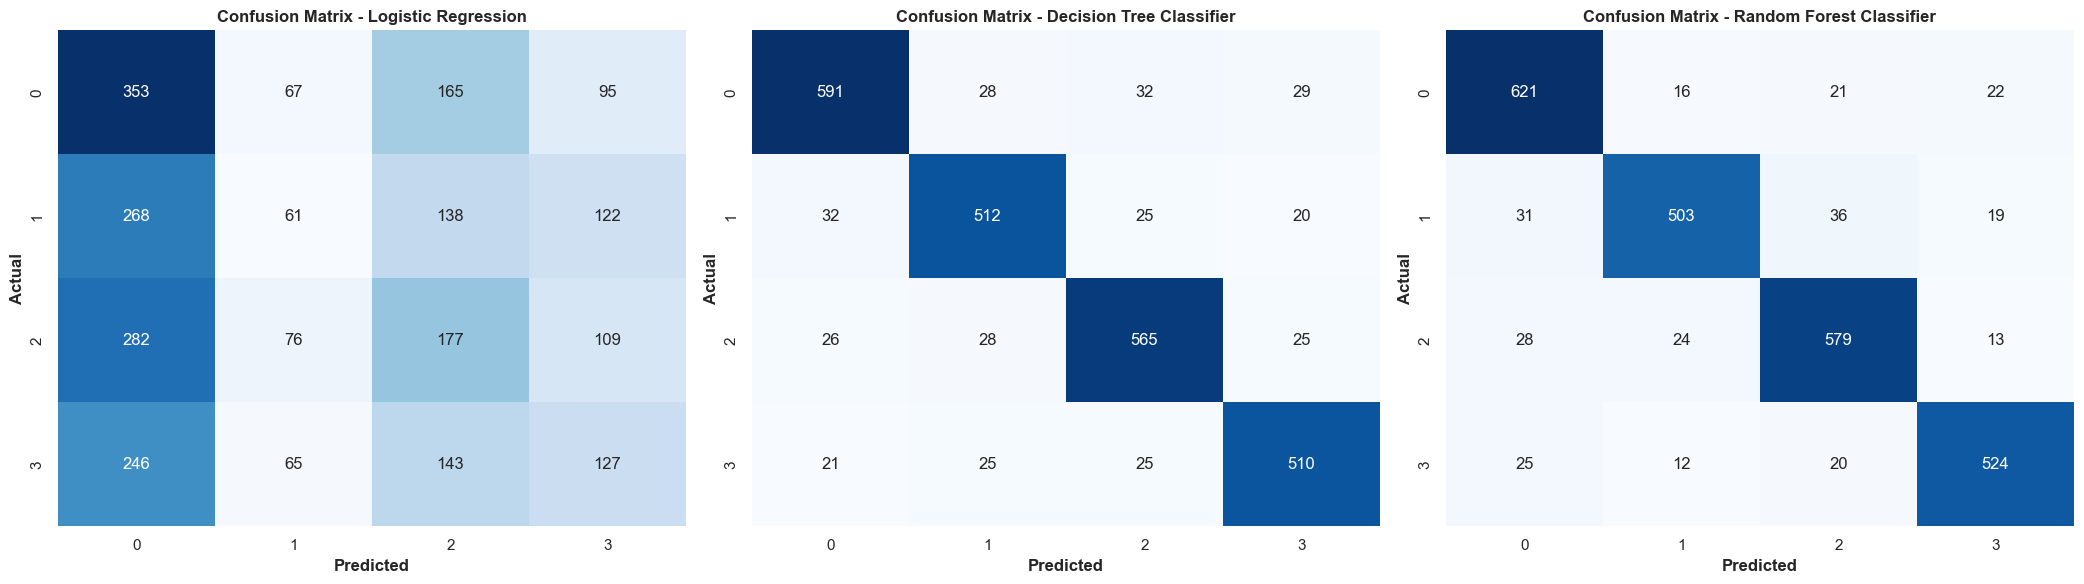


Logistic Regression
              precision    recall  f1-score   support

           0       0.31      0.52      0.39       680
           1       0.23      0.10      0.14       589
           2       0.28      0.27      0.28       644
           3       0.28      0.22      0.25       581

    accuracy                           0.29      2494
   macro avg       0.27      0.28      0.26      2494
weighted avg       0.28      0.29      0.27      2494


Decision Tree Classifier
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       680
           1       0.86      0.87      0.87       589
           2       0.87      0.88      0.88       644
           3       0.87      0.88      0.88       581

    accuracy                           0.87      2494
   macro avg       0.87      0.87      0.87      2494
weighted avg       0.87      0.87      0.87      2494


Random Forest Classifier
              precision    recall  f1-score   support

  

In [8]:
# Classification modelling for FinalGrade prediction

classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=200, random_state=42)
}

classification_results = []
classification_labels = sorted(y_clf.unique())

for model_name, model in classification_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", classification_preprocessor),
            ("model", model)
        ]
    )
    pipeline.fit(X_clf_train, y_clf_train)
    predictions = pipeline.predict(X_clf_test)
    confusion = confusion_matrix(y_clf_test, predictions, labels=classification_labels)

    classification_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_clf_test, predictions),
        "Precision": precision_score(y_clf_test, predictions, average="weighted", zero_division=0),
        "Recall": recall_score(y_clf_test, predictions, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_clf_test, predictions, average="weighted", zero_division=0),
        "Confusion Matrix": confusion,
        "Classification Report": classification_report(y_clf_test, predictions, zero_division=0)
    })

classification_results_df = pd.DataFrame([
    {k: v for k, v in result.items() if k not in ["Confusion Matrix", "Classification Report"]}
    for result in classification_results
]).sort_values(["F1 Score", "Accuracy"], ascending=False).reset_index(drop=True)

display(classification_results_df)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, result in zip(axes, classification_results):
    sns.heatmap(
        result["Confusion Matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    ax.set_title(f"Confusion Matrix - {result['Model']}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

for result in classification_results:
    print(f"\n{result['Model']}")
    print(result["Classification Report"])


### Classification Observations

The classification results will highlight how well the same student behavior features separate FinalGrade groups. Ensemble models typically perform better here because they can capture mixed feature effects and non-linear grade patterns.

## 10. Model Comparison

This section compares the regression and classification models side by side. The goal is to identify the strongest predictive setup while keeping the workflow simple, interpretable, and presentation-ready.

,Model,MAE,RMSE,R2
0,Random Forest Regressor,4.999463,7.898565,0.801922
1,Decision Tree Regressor,3.208500,9.610998,0.706724
2,Linear Regression,15.343311,17.705249,0.004725


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest Classifier,0.892943,0.893313,0.892943,0.892843
1,Decision Tree Classifier,0.873296,0.873347,0.873296,0.873303
2,Logistic Regression,0.287891,0.275994,0.287891,0.268199


Best regression model: Random Forest Regressor | RMSE = 7.899 | R2 = 0.802
Best classification model: Random Forest Classifier | F1 Score = 0.893 | Accuracy = 0.893


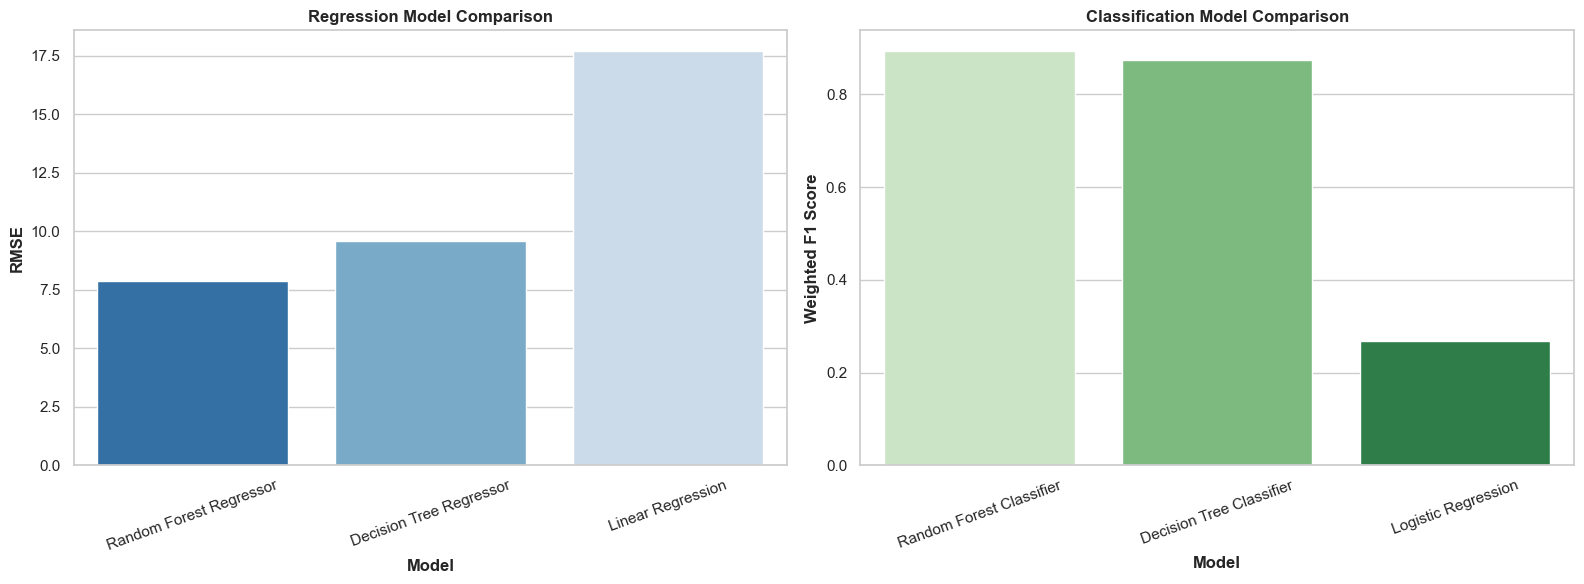

In [9]:
# Compare the fitted models and summarize the best performers

display(regression_results_df)
display(classification_results_df)

best_regression = regression_results_df.sort_values("RMSE").iloc[0]
best_classification = classification_results_df.sort_values(["F1 Score", "Accuracy"], ascending=False).iloc[0]

print(f"Best regression model: {best_regression['Model']} | RMSE = {best_regression['RMSE']:.3f} | R2 = {best_regression['R2']:.3f}")
print(f"Best classification model: {best_classification['Model']} | F1 Score = {best_classification['F1 Score']:.3f} | Accuracy = {best_classification['Accuracy']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=regression_results_df, x="Model", y="RMSE", ax=axes[0], palette="Blues_r")
axes[0].set_title("Regression Model Comparison")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=classification_results_df, x="Model", y="F1 Score", ax=axes[1], palette="Greens")
axes[1].set_title("Classification Model Comparison")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Weighted F1 Score")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 11. Business Insights and Recommendations

- Higher study effort and stronger attendance patterns should be treated as the most important engagement signals.
- Students with higher stress levels may benefit from early support, nudges, and monitoring.
- Assignment completion and online learning activity can help identify students who need follow-up.
- EdTech platforms should personalize reminders, practice tasks, and progress dashboards.
- Institutions can improve outcomes by combining academic monitoring with student well-being support.

## 12. Conclusion

This project delivered a complete EdTech analytics workflow from raw data inspection to predictive modeling. The analysis linked study behavior, attendance, stress, and technology usage with student performance, while the machine learning models provided a practical baseline for prediction tasks.

**Key findings**
- Study behavior and attendance are among the most useful performance signals.
- Stress and engagement patterns help explain differences in academic outcomes.
- Tree-based models are a strong fit for this dataset because they capture non-linear relationships.

**Future improvements**
- Apply hyperparameter tuning and cross-validation.
- Explore ordinal modeling for FinalGrade.
- Add feature importance, SHAP analysis, and more intervention-focused metrics.